# 04 · Análisis temporal

**Este es el notebook que justifica que el proyecto exista.**

Los tres anteriores caracterizan la población tal como era en el periodo de
referencia. Este pregunta otra cosa: **¿sigue siendo esa la población?**

Es la pregunta que casi ningún EDA de portafolio se hace, y es la única que
importa cuando un modelo lleva meses en producción. Un modelo no se estropea
solo; se estropea porque el mundo que describía dejó de ser el mismo.

Lo que se busca aquí es distinguir dos fenómenos que se confunden
constantemente:

| | Qué cambia | Qué le pasa al modelo |
|---|---|---|
| **Data drift** | La distribución de las variables de entrada | Nada necesariamente. Puede seguir siendo perfectamente válido |
| **Concept drift** | La relación entre las variables y el objetivo | Se degrada. Lo que aprendió ya no describe la realidad |

Confundirlos sale caro en las dos direcciones: reentrenar por cada alerta de
data drift es quemar dinero, y no vigilar el concept drift es servir
predicciones malas sin enterarse.

Todo lo que aparece a continuación se detecta **a simple vista**, antes de
instrumentar nada. Evidently, en la Fase 8, no descubrirá nada nuevo: pondrá
número y automatizará lo que aquí ya se ve.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1]))

import numpy as np
import pandas as pd

from src.config import REFERENCE_MONTHS, TARGET
from src.data.generate_data import load_raw, regime_for
from src.viz import (
    INK_MUTED,
    REGIME_COLORS,
    REGIME_LABELS,
    SERIES,
    STATUS,
    annotate_regimes,
    plt,
    save_figure,
    set_style,
)

set_style()

df = load_raw()
meses = sorted(df.snapshot_month.unique())
df["regimen"] = df.snapshot_month.map({m: regime_for(i) for i, m in enumerate(meses)})

print(f"{len(meses)} meses: de {meses[0]} a {meses[-1]}")
print(
    f"Periodo de referencia (con el que se entrena): {REFERENCE_MONTHS[0]} .. {REFERENCE_MONTHS[-1]}"
)

18 meses: de 2024-01 a 2025-06
Periodo de referencia (con el que se entrena): 2024-01 .. 2024-08


## 1. Lo que NO cambia: la tasa de churn

Empezar por aquí no es un rodeo. Si la tasa base se moviera, cualquier
comparación posterior quedaría contaminada y no se podría atribuir nada.

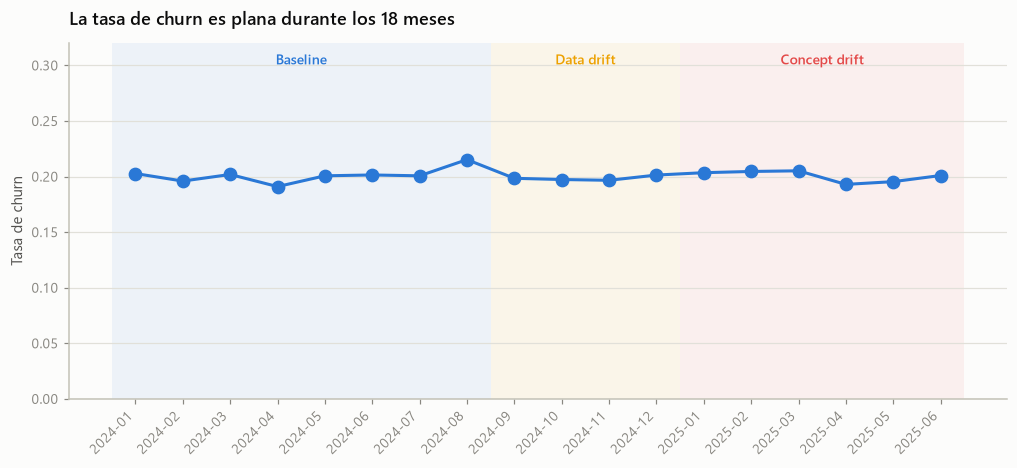

In [2]:
por_mes = df.groupby("snapshot_month").agg(tasa_churn=(TARGET, "mean"), clientes=(TARGET, "size"))

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(range(len(meses)), por_mes.tasa_churn, marker="o", color=SERIES[0], zorder=3)
ax.set_ylim(0, 0.32)
annotate_regimes(ax, meses, y=0.31)
ax.set_xticks(range(len(meses)), meses, rotation=45, ha="right")
ax.set_ylabel("Tasa de churn")
ax.set_title("La tasa de churn es plana durante los 18 meses")
plt.show()

> **Conclusión.** Entre el 19 % y el 21,5 %, sin tendencia ni saltos.
>
> Este gráfico es el control del experimento: **nada de lo que venga después se
> puede explicar diciendo "es que ahora se va más o menos gente"**. La
> prevalencia está fija.
>
> Consecuencia práctica: un sistema de monitoreo que solo vigilara la tasa de
> churn no detectaría absolutamente nada de lo que ocurre en este dataset. Y
> vigilar la tasa base es exactamente lo que hacen muchos dashboards de negocio.

## 2. Data drift: la distribución de entrada sí cambia

A partir de 2024-09 se lanza un plan de datos ilimitado. El consumo mensual
empieza a subir de forma progresiva.

figura guardada: docs/img/04_data_drift_uso.png


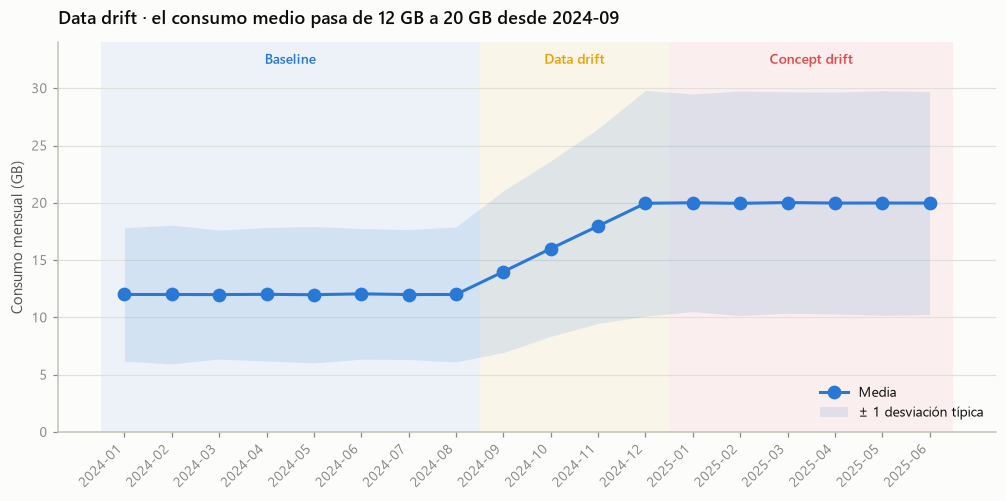

In [3]:
uso_mes = df.groupby("snapshot_month").monthly_usage_gb.agg(["mean", "median", "std"])

fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(meses))
ax.plot(x, uso_mes["mean"], marker="o", color=SERIES[0], label="Media", zorder=3)
ax.fill_between(
    x,
    uso_mes["mean"] - uso_mes["std"],
    uso_mes["mean"] + uso_mes["std"],
    color=SERIES[0],
    alpha=0.13,
    linewidth=0,
    label="± 1 desviación típica",
)
ax.set_ylim(0, 34)
annotate_regimes(ax, meses, y=33)
ax.set_xticks(x, meses, rotation=45, ha="right")
ax.set_ylabel("Consumo mensual (GB)")
ax.set_title("Data drift · el consumo medio pasa de 12 GB a 20 GB desde 2024-09")
ax.legend(loc="lower right")
save_figure(fig, "04_data_drift_uso")
plt.show()

La rampa es progresiva, no un escalón. Es lo habitual en producción — los
cambios de comportamiento se propagan por la base de clientes, no ocurren de un
día para otro — y es lo que hace que la detección sea un problema real y no un
ejercicio trivial.

Visto como distribuciones completas, en vez de como una media:

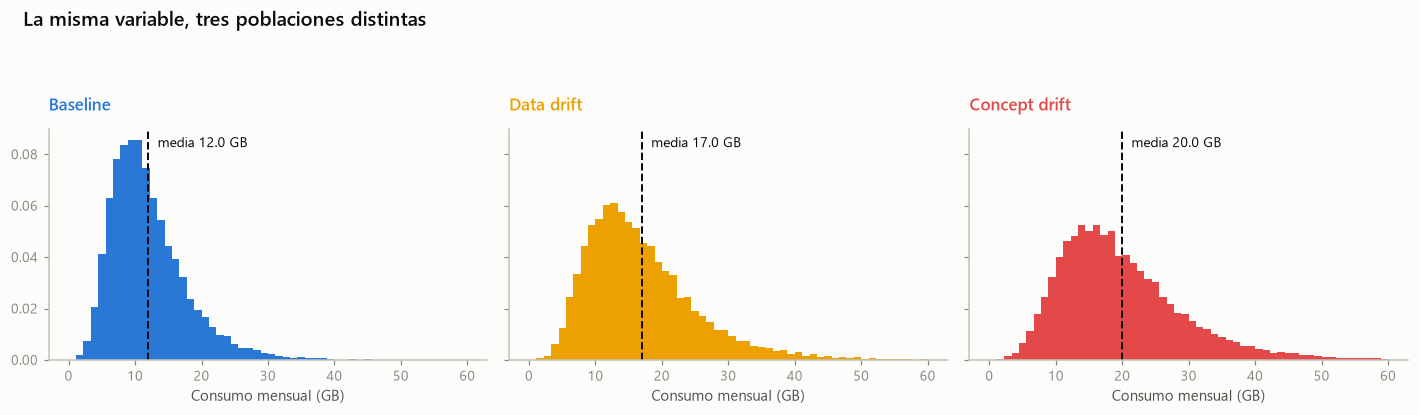

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, sharey=True)
for ax, (regimen, grupo) in zip(axes, df.groupby("regimen", sort=False), strict=True):
    ax.hist(
        grupo.monthly_usage_gb,
        bins=np.linspace(0, 60, 55),
        color=REGIME_COLORS[regimen],
        edgecolor="none",
        density=True,
    )
    ax.axvline(grupo.monthly_usage_gb.mean(), color="#0b0b0b", linestyle="--", linewidth=1.3)
    ax.annotate(
        f"media {grupo.monthly_usage_gb.mean():.1f} GB",
        xy=(grupo.monthly_usage_gb.mean(), ax.get_ylim()[1]),
        xytext=(6, -12),
        textcoords="offset points",
        fontsize=9,
        color="#0b0b0b",
    )
    ax.set_title(REGIME_LABELS[regimen], color=REGIME_COLORS[regimen], fontsize=11)
    ax.set_xlabel("Consumo mensual (GB)")
    ax.grid(False)
fig.suptitle(
    "La misma variable, tres poblaciones distintas",
    x=0.02,
    ha="left",
    fontsize=13,
    fontweight="semibold",
)
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

También cambia la composición del método de pago: migración desde el cheque
electrónico hacia los pagos automáticos.

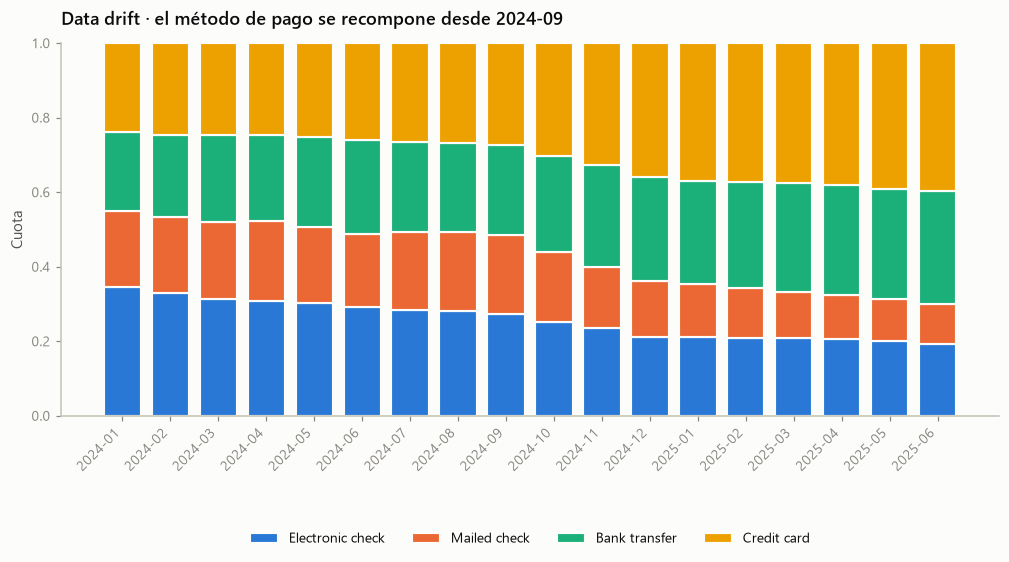

In [5]:
reparto = df.groupby(["snapshot_month", "payment_method"]).size().unstack(fill_value=0)
reparto = reparto.div(reparto.sum(axis=1), axis=0)
orden = ["Electronic check", "Mailed check", "Bank transfer", "Credit card"]
reparto = reparto[orden]

fig, ax = plt.subplots(figsize=(11, 4.4))
abajo = np.zeros(len(reparto))
for i, metodo in enumerate(orden):
    valores = reparto[metodo].to_numpy()
    ax.bar(
        range(len(reparto)),
        valores,
        bottom=abajo,
        color=SERIES[i],
        label=metodo,
        width=0.78,
        linewidth=1.4,
        edgecolor="#fcfcfb",
    )
    abajo += valores
ax.set_xticks(range(len(reparto)), reparto.index, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Cuota")
ax.set_title("Data drift · el método de pago se recompone desde 2024-09")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.28))
ax.grid(False)
plt.show()

> **Conclusión — data drift confirmado.** Dos variables de entrada cambian de
> distribución a partir de 2024-09, de forma clara y sostenida.
>
> **La pregunta que casi nadie hace: ¿y eso importa?** Un cambio de distribución
> es un hecho sobre los datos, no un veredicto sobre el modelo. Para saber si
> importa hay que mirar si la *relación* con el objetivo se mantiene. Es lo que
> viene ahora.

## 3. Concept drift: la relación con el objetivo se rompe

En el notebook 03, `support_tickets_30d` era el mejor predictor de
comportamiento del periodo de referencia. La pregunta es si sigue siéndolo.

Se calcula la correlación punto-biserial entre cada variable y `churn`,
**mes a mes**. Si la relación es estable, la línea es plana.

figura guardada: docs/img/04_concept_drift_tickets.png


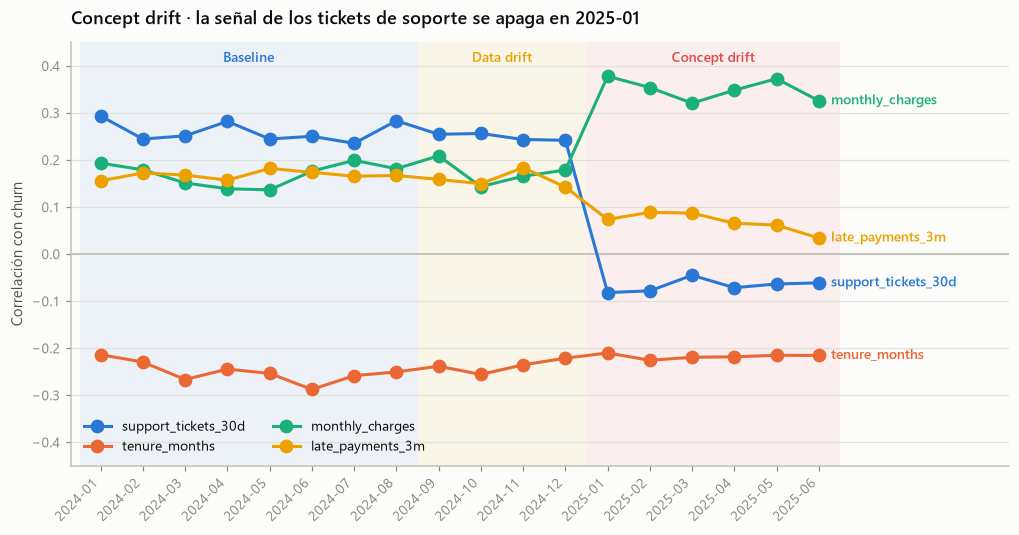

In [6]:
def correlacion_mensual(columna: str) -> pd.Series:
    return df.groupby("snapshot_month").apply(
        lambda g: g[columna].corr(g[TARGET]), include_groups=False
    )


vigiladas = ["support_tickets_30d", "tenure_months", "monthly_charges", "late_payments_3m"]
correlaciones = pd.DataFrame({c: correlacion_mensual(c) for c in vigiladas})

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(meses))
for i, columna in enumerate(vigiladas):
    ax.plot(x, correlaciones[columna], marker="o", color=SERIES[i], label=columna, zorder=3)
    ax.annotate(
        columna,
        xy=(x[-1], correlaciones[columna].iloc[-1]),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
        color=SERIES[i],
        fontweight="semibold",
    )
ax.axhline(0, color="#c3c2b7", linewidth=1.2)
ax.set_ylim(-0.45, 0.45)
annotate_regimes(ax, meses, y=0.43)
ax.set_xticks(x, meses, rotation=45, ha="right")
ax.set_xlim(-0.7, len(meses) + 3.5)
ax.set_ylabel("Correlación con churn")
ax.set_title("Concept drift · la señal de los tickets de soporte se apaga en 2025-01")
ax.legend(loc="lower left", ncol=2)
save_figure(fig, "04_concept_drift_tickets")
plt.show()

**Ahí está la ruptura.** `support_tickets_30d` mantiene una correlación estable
en torno a +0,25 durante trece meses — incluido todo el periodo de data drift —
y en 2025-01 cae a cero de golpe.

La lectura de negocio: se lanza un programa de retención proactiva que contacta
a los clientes que abren tickets. A partir de ese momento, quejarse deja de ser
señal de que te vas: es señal de que alguien te va a llamar para retenerte.

Al mismo tiempo, `monthly_charges` gana peso. El motor del churn se ha
desplazado del descontento al precio.

In [7]:
resumen = pd.DataFrame(
    {
        "referencia (2024-01..08)": correlaciones.iloc[:8].mean(),
        "data drift (2024-09..12)": correlaciones.iloc[8:12].mean(),
        "concept drift (2025-01..06)": correlaciones.iloc[12:].mean(),
    }
).round(3)
resumen["cambio"] = (
    resumen["concept drift (2025-01..06)"] - resumen["referencia (2024-01..08)"]
).round(3)
resumen

,referencia (2024-01..08),data drift (2024-09..12),concept drift (2025-01..06),cambio
support_tickets_30d,0.261,0.249,-0.067,-0.328
tenure_months,-0.250,-0.237,-0.217,0.033
monthly_charges,0.170,0.174,0.350,0.180
late_payments_3m,0.168,0.159,0.069,-0.099


## 4. El mismo fenómeno, visto desde el contrato

Si el precio pasa a dominar, el efecto del tipo de contrato debería
intensificarse. Se puede comprobar.

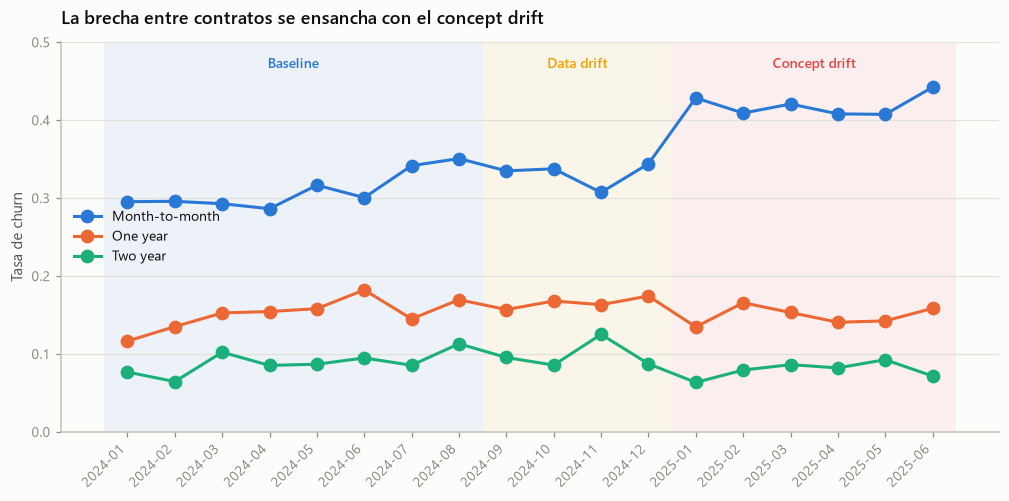

In [8]:
por_contrato = df.groupby(["snapshot_month", "contract_type"])[TARGET].mean().unstack()
orden_contratos = ["Month-to-month", "One year", "Two year"]

fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(meses))
for i, contrato in enumerate(orden_contratos):
    ax.plot(x, por_contrato[contrato], marker="o", color=SERIES[i], label=contrato, zorder=3)
ax.set_ylim(0, 0.5)
annotate_regimes(ax, meses, y=0.48)
ax.set_xticks(x, meses, rotation=45, ha="right")
ax.set_ylabel("Tasa de churn")
ax.set_title("La brecha entre contratos se ensancha con el concept drift")
ax.legend(loc="center left")
plt.show()

In [9]:
brecha = (por_contrato["Month-to-month"] - por_contrato["Two year"]).rename("brecha")
print("Brecha media de tasa de churn entre contrato mensual y de dos años:")
print(f"  referencia    : {brecha.iloc[:8].mean():.1%}")
print(f"  data drift    : {brecha.iloc[8:12].mean():.1%}")
print(f"  concept drift : {brecha.iloc[12:].mean():.1%}")

Brecha media de tasa de churn entre contrato mensual y de dos años:
  referencia    : 22.1%
  data drift    : 23.3%
  concept drift : 34.0%


> **Conclusión — concept drift confirmado.** La brecha entre contratos se
> ensancha claramente en 2025. Es el mismo fenómeno visto desde otro ángulo: el
> peso se ha desplazado hacia las variables contractuales y de precio.

---
## Conclusiones de este notebook

Se han identificado **dos eventos distintos, en dos momentos distintos**:

| Cuándo | Qué | Cómo se detecta | Qué hay que hacer |
|---|---|---|---|
| **2024-09** | Data drift: cambia la distribución de `monthly_usage_gb` y `payment_method` | Comparando distribuciones de entrada contra la referencia | **Vigilar, no reentrenar.** La relación con el objetivo sigue intacta |
| **2025-01** | Concept drift: `support_tickets_30d` deja de predecir el churn | Comparando la relación variable–objetivo, o midiendo el rendimiento del modelo | **Reentrenar.** Lo que el modelo aprendió ya no es cierto |

### Qué implica esto para el resto del proyecto

1. **Fase 3 (entrenamiento).** El split tiene que ser temporal, no aleatorio. Un
   split aleatorio mezclaría los tres regímenes y produciría una métrica de
   validación optimista que no se parecería en nada al rendimiento real.

2. **Fase 8 (monitoreo).** Vigilar solo el drift de datos es insuficiente:
   dispararía una alarma en 2024-09, cuando el modelo está perfectamente sano.
   Vigilar solo el rendimiento tampoco basta, porque en producción las etiquetas
   reales llegan con semanas de retraso. Hacen falta **las dos señales**, y hay
   que saber leerlas juntas:

   | Drift de datos | Rendimiento | Interpretación |
   |---|---|---|
   | No | Estable | Todo en orden |
   | **Sí** | **Estable** | Cambió la población, el modelo sigue siendo válido → vigilar |
   | Sí o no | **Cae** | Concept drift → reentrenar |

3. **La expectativa concreta que hay que verificar en la Fase 8:** un modelo
   entrenado con 2024-01..06 debería mantener su AUC durante el data drift y
   perderlo a partir de 2025-01. Si el monitoreo no reproduce ese patrón, es el
   monitoreo el que está mal, no los datos.

**Siguiente:** Fase 3 — construir el pipeline de features con todas las
decisiones acumuladas en estos cuatro notebooks, y entrenar los modelos.